In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Plot style
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/raw/HDFC_Top100_NAV.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3109, 2)


,date,nav
0,25-06-2026,203.9157
1,24-06-2026,205.0655
2,23-06-2026,203.5443
3,22-06-2026,204.1263
4,19-06-2026,202.0761


In [3]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Sort data by date (oldest to newest)
df = df.sort_values("date")

# Check data types
df.dtypes

date    datetime64[ns]
nav            float64
dtype: object

In [4]:
# Calculate daily returns
df["daily_return"] = df["nav"].pct_change()

# Display first few rows
df.head()

,date,nav,daily_return
3108,2013-11-18,13.0894,NaN
3107,2013-11-19,13.1068,0.001329
3106,2013-11-20,12.9549,-0.011589
3105,2013-11-21,12.7957,-0.012289
3104,2013-11-22,12.7775,-0.001422


In [5]:
# Summary statistics of daily returns
df["daily_return"].describe()

count    3108.000000
mean        0.000930
std         0.009574
min        -0.096964
25%        -0.003340
50%         0.001502
75%         0.006263
max         0.046026
Name: daily_return, dtype: float64

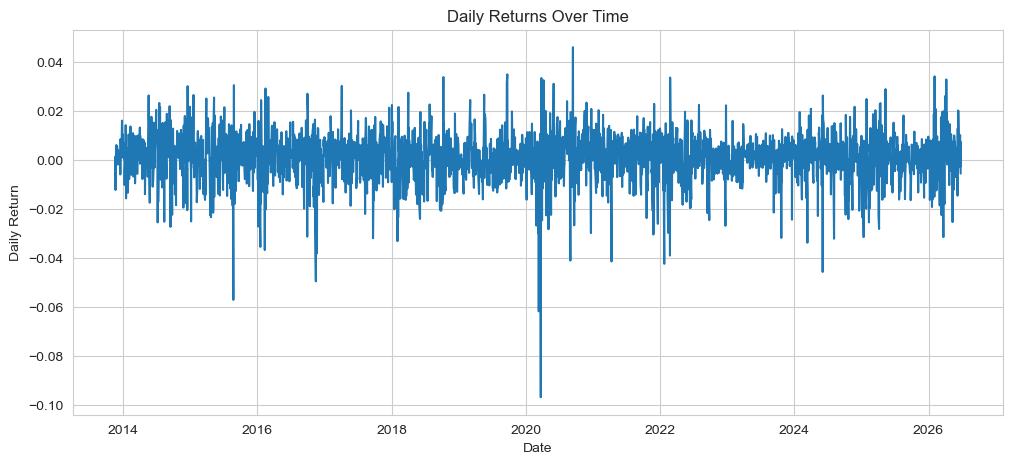

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["daily_return"])

plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

In [7]:
# Running maximum NAV
df["running_max"] = df["nav"].cummax()

# Drawdown
df["drawdown"] = (df["nav"] - df["running_max"]) / df["running_max"]

# Maximum Drawdown
max_drawdown = df["drawdown"].min()

print("Maximum Drawdown:", round(max_drawdown * 100, 2), "%")

Maximum Drawdown: -40.26 %


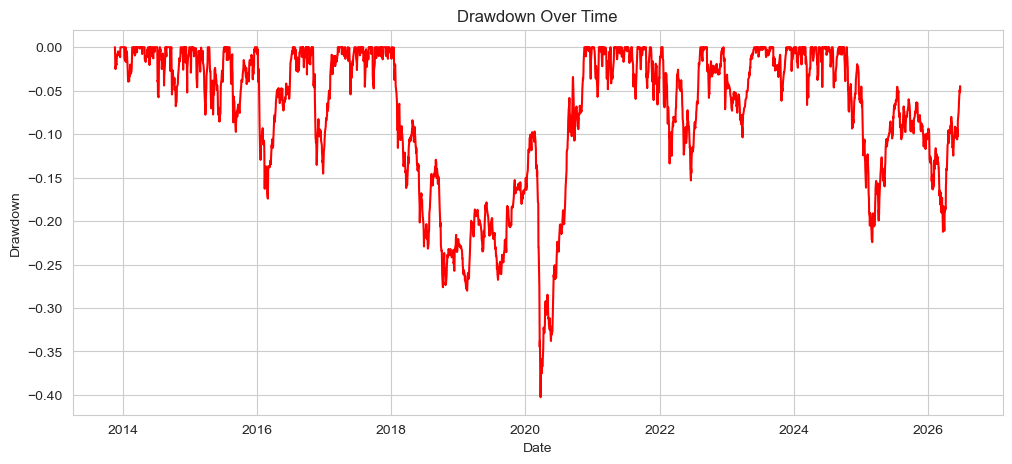

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["drawdown"], color="red")

plt.title("Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()

In [9]:
VaR_95 = df["daily_return"].quantile(0.05)

print("95% Value at Risk (VaR):", round(VaR_95 * 100, 2), "%")

95% Value at Risk (VaR): -1.51 %


In [10]:
risk_free_rate = 0

sharpe_ratio = (
    (df["daily_return"].mean() - risk_free_rate)
    / df["daily_return"].std()
)

print("Sharpe Ratio:", round(sharpe_ratio, 4))

Sharpe Ratio: 0.0971


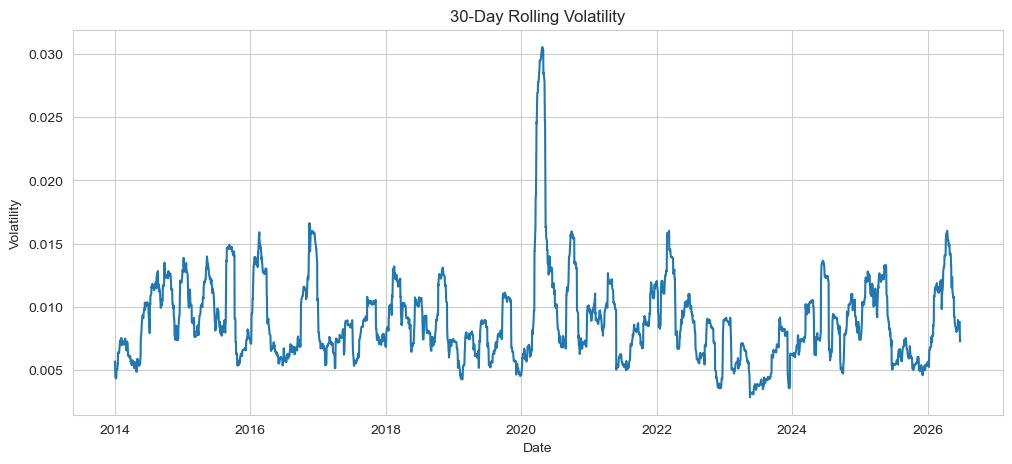

In [11]:
df["rolling_volatility"] = df["daily_return"].rolling(30).std()

plt.figure(figsize=(12,5))

plt.plot(df["date"], df["rolling_volatility"])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()